# 04 Model Training 1D CNN with Attention

Train a 1D CNN with attention on the preprocessed MIT-BIH beats.
This notebook:
- loads preprocessed `.npz` files,
- prepares data (train/val split, one-hot labels),
- builds 1D CNN + attention,
- trains with callbacks and class weighting,
- plots training curves,
- performs extensive evaluation (confusion matrix, classification report, ROC/AUC),
- saves trained model and label encoder.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import Counter

# ML libs
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:
PREPROCESSED_DIR = "../Data/Processed"   # adjust if needed
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 1e-3
TEST_SIZE = 0.2   # validation fraction
RANDOM_STATE = SEED

# Model input shape placeholder (set after loading data)
INPUT_SHAPE = None
NUM_CLASSES = None


In [6]:
# Collect all npz files
files = [f for f in os.listdir(PREPROCESSED_DIR) if f.endswith('.npz')]
files = sorted(files)
print("Found preprocessed files:", len(files))

X_list = []
y_list = []

for fn in files:
    data = np.load(os.path.join(PREPROCESSED_DIR, fn), allow_pickle=True)
    beats = data['beats']    # shape: (n_beats, beat_length)
    labels = data['labels']  # list/array of string labels (AAMI classes)
    # convert to numpy array if needed
    if isinstance(labels, np.ndarray) and labels.dtype == object:
        labels = labels.tolist()

    # extend
    X_list.append(beats)
    y_list.extend(labels)

# stack
X = np.vstack(X_list)   # shape: (N, L)
y = np.array(y_list)
print("X shape:", X.shape, "y shape:", y.shape)


Found preprocessed files: 47
X shape: (97737, 250) y shape: (97737,)


In [7]:
# Show class distribution
dist = Counter(y)
print("Class distribution (raw):", dist)

# Label encode
le = LabelEncoder()
y_int = le.fit_transform(y)    # integers 0..C-1
classes = list(le.classes_)
NUM_CLASSES = len(classes)
print("Classes:", classes)

# One-hot
y_onehot = tf.keras.utils.to_categorical(y_int, num_classes=NUM_CLASSES)


Class distribution (raw): Counter({'N': 88710, 'V': 5543, 'S': 2692, 'F': 792})
Classes: ['F', 'N', 'S', 'V']


In [14]:
with open(os.path.join(MODEL_DIR, "label_encoder.json"), "w") as f:
    json.dump({"classes": classes}, f)


In [16]:
# ensure float32
X = X.astype(np.float32)

# If dataset normalized per-beat already, it's fine.
# Ensure shape: (N, L, 1) for Conv1D
X = X.reshape((X.shape[0], X.shape[1], 1))
INPUT_SHAPE = X.shape[1:]
print("INPUT_SHAPE:", INPUT_SHAPE)


INPUT_SHAPE: (250, 1)


In [18]:
print("X shape =", X.shape)
print("y shape =", y.shape)

X shape = (97737, 250, 1)
y shape = (97737,)


In [20]:
# We'll use stratified split on integer labels
X_train, X_val, y_train, y_val = train_test_split(
    X, y_onehot, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_int
)

print("Train:", X_train.shape, "Val:", X_val.shape)


Train: (78189, 250, 1) Val: (19548, 250, 1)


In [22]:
# class weight computation
y_train_int = np.argmax(y_train, axis=1)
class_counts = Counter(y_train_int)
total = sum(class_counts.values())
class_weight = {cls: (total / (len(class_counts) * count)) for cls, count in class_counts.items()}
print("Class weights:", class_weight)


Class weights: {1: 0.2754414023419336, 2: 9.074860724233984, 3: 4.408491204330176, 0: 30.831624605678233}


In [24]:
from tensorflow.keras import layers, models, optimizers

def attention_block(inputs):
    """
    Simple attention mechanism compatible with Keras Functional API.
    inputs: (batch, timesteps, channels)
    returns: same shape as inputs (weighted by attention)
    """
    # Compute attention scores
    score = layers.Dense(1, activation='tanh')(inputs)  # (batch, timesteps, 1)
    score = layers.Flatten()(score)                     # (batch, timesteps)
    att_weights = layers.Activation('softmax', name='attention_weights')(score)  # (batch, timesteps)
    att_weights = layers.RepeatVector(inputs.shape[-1])(att_weights)  # (channels, batch, timesteps)
    att_weights = layers.Permute([2,1])(att_weights)    # (batch, timesteps, channels)

    # Multiply attention weights
    attended = layers.Multiply()([inputs, att_weights])  # (batch, timesteps, channels)
    return attended

def build_model(input_shape, num_classes, lr=1e-3):
    inp = layers.Input(shape=input_shape, name='ecg_input')  # (L,1)

    # Conv layers
    x = layers.Conv1D(32, kernel_size=9, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(64, kernel_size=7, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Attention
    x = attention_block(x)  # returns attended tensor

    # Global pooling + Dense
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    # Compile model
    model = models.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Build model
model = build_model(INPUT_SHAPE, NUM_CLASSES, lr=LEARNING_RATE)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)        │ (None, 250, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 250, 32)           │             320 │ ecg_input[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 250, 32)           │             128 │ conv1d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d (MaxPooling1D)  │ (None, 125, 32)           │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 125, 64)           │          14,400 │ max_pooling1d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 125, 64)           │             256 │ conv1d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_1               │ (None, 62, 64)            │               0 │ batch_normalization_1[0][… │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 62, 128)           │          41,088 │ max_pooling1d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 62, 128)           │             512 │ conv1d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 62, 1)             │             129 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 62)                │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_weights             │ (None, 62)                │               0 │ flatten[0][0]              │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ repeat_vector (RepeatVector)  │ (None, 128, 62)           │               0 │ attention_weights[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ permute (Permute)             │ (None, 62, 128)           │               0 │ repeat_vector[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, 62, 128)           │               

 Total params: 73,861 (288.52 KB)

 Trainable params: 73,413 (286.77 KB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
cb_early = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
cb_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
cb_checkpoint = callbacks.ModelCheckpoint(os.path.join(MODEL_DIR, "best_model.h5"),
                                          monitor='val_loss', save_best_only=True)
tensorboard_cb = callbacks.TensorBoard(log_dir=os.path.join(MODEL_DIR, "tb_logs"))


In [28]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[cb_early, cb_lr, cb_checkpoint, tensorboard_cb],
    class_weight=class_weight,
    verbose=2
)

Epoch 1/20


1222/1222 - 60s - 49ms/step - accuracy: 0.6366 - loss: 0.7177 - val_accuracy: 0.8479 - val_loss: 0.5543 - learning_rate: 0.0010
Epoch 2/20


1222/1222 - 41s - 33ms/step - accuracy: 0.8001 - loss: 0.4789 - val_accuracy: 0.8377 - val_loss: 0.5177 - learning_rate: 0.0010
Epoch 3/20


1222/1222 - 42s - 34ms/step - accuracy: 0.8379 - loss: 0.4153 - val_accuracy: 0.8995 - val_loss: 0.3881 - learning_rate: 0.0010
Epoch 4/20


1222/1222 - 44s - 36ms/step - accuracy: 0.8461 - loss: 0.3808 - val_accuracy: 0.9081 - val_loss: 0.3588 - learning_rate: 0.0010
Epoch 5/20


...

1222/1222 - 42s - 35ms/step - accuracy: 0.9024 - loss: 0.2230 - val_accuracy: 0.9201 - val_loss: 0.2429 - learning_rate: 0.0010
Epoch 11/20


1222/1222 - 43s - 35ms/step - accuracy: 0.9076 - loss: 0.2084 - val_accuracy: 0.9299 - val_loss: 0.2342 - learning_rate: 0.0010
Epoch 12/20
1222/1222 - 42s - 34ms/step - accuracy: 0.9163 - loss: 0.1916 - val_accuracy: 0.9065 - val_loss: 0.2690 - learning_rate: 0.0010
Epoch 13/20
1222/1222 - 42s - 34ms/step - accuracy: 0.9170 - loss: 0.1844 - val_accuracy: 0.9154 - val_loss: 0.2582 - learning_rate: 0.0010
Epoch 14/20
1222/1222 - 81s - 66ms/step - accuracy: 0.9207 - loss: 0.1759 - val_accuracy: 0.9209 - val_loss: 0.2577 - learning_rate: 0.0010
Epoch 15/20


1222/1222 - 44s - 36ms/step - accuracy: 0.9342 - loss: 0.1433 - val_accuracy: 0.9491 - val_loss: 0.1612 - learning_rate: 5.0000e-04
Epoch 16/20


1222/1222 - 40s - 32ms/step - accuracy: 0.9396 - loss: 0.1285 - val_accuracy: 0.9507 - val_loss: 0.1579 - learning_rate: 5.0000e-04
Epoch 17/20


1222/1222 - 40s - 33ms/step - accuracy: 0.9446 - loss: 0.1157 - val_accuracy: 0.9543 - val_loss: 0.1431 - learning_rate: 5.0000e-04
Epoch 18/20
1222/1222 - 41s - 34ms/step - accuracy: 0.9405 - loss: 0.1213 - val_accuracy: 0.9487 - val_loss: 0.1572 - learning_rate: 5.0000e-04
Epoch 19/20
1222/1222 - 43s - 35ms/step - accuracy: 0.9485 - loss: 0.1057 - val_accuracy: 0.9483 - val_loss: 0.1583 - learning_rate: 5.0000e-04
Epoch 20/20
1222/1222 - 43s - 35ms/step - accuracy: 0.9496 - loss: 0.1014 - val_accuracy: 0.9358 - val_loss: 0.1922 - learning_rate: 5.0000e-04


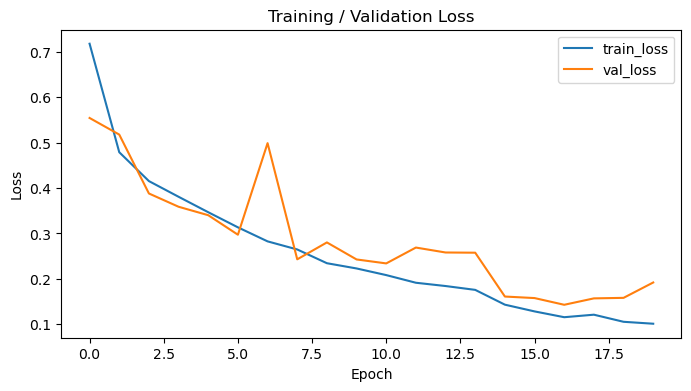

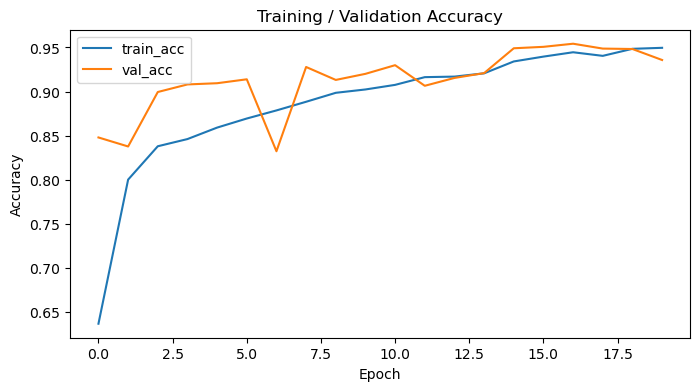

In [30]:
# Loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Training / Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Training / Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [32]:
best_model_path = os.path.join(MODEL_DIR, "best_model.h5")
if os.path.exists(best_model_path):
    best = models.load_model(best_model_path, compile=True)
else:
    best = model  # use in-memory model if checkpoint absent

val_preds = best.predict(X_val, batch_size=BATCH_SIZE)
y_val_int = np.argmax(y_val, axis=1)
y_pred_int = np.argmax(val_preds, axis=1)


306/306 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [34]:
cm = confusion_matrix(y_val_int, y_pred_int)
print("Confusion matrix:\n", cm)

print("\nClassification report:\n")
print(classification_report(y_val_int, y_pred_int, target_names=classes, digits=4))


Confusion matrix:
 [[  144     8     2     4]
 [  212 16974   444   113]
 [    3    55   475     5]
 [   33    11     4  1061]]

Classification report:

              precision    recall  f1-score   support

           F     0.3673    0.9114    0.5236       158
           N     0.9957    0.9567    0.9758     17743
           S     0.5135    0.8829    0.6494       538
           V     0.8969    0.9567    0.9258      1109

    accuracy                         0.9543     19548
   macro avg     0.6933    0.9269    0.7686     19548
weighted avg     0.9717    0.9543    0.9603     19548



In [36]:
report_dict = classification_report(y_val_int, y_pred_int, target_names=classes, output_dict=True)
# save
with open(os.path.join(MODEL_DIR, "classification_report.json"), "w") as f:
    json.dump(report_dict, f, indent=2)


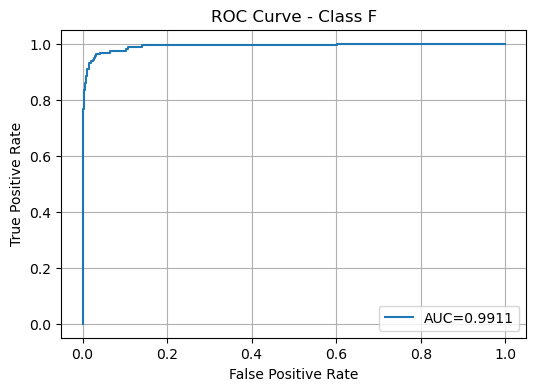

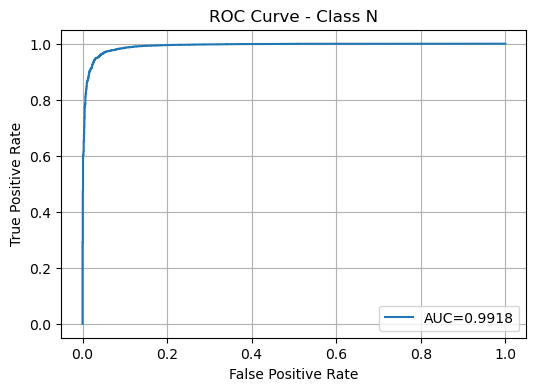

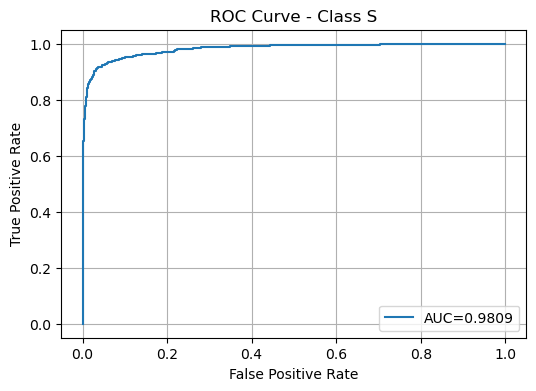

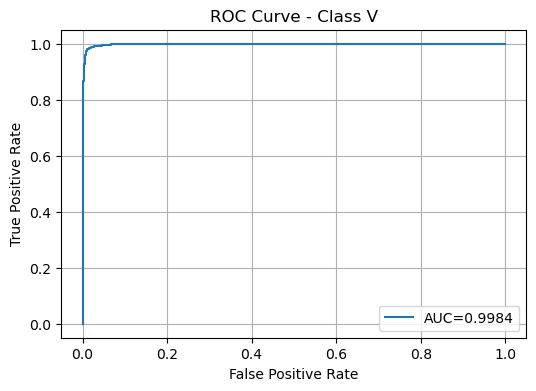

Macro-Average AUC: 0.9906


In [38]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Ensure classes variable is defined
if 'classes' not in globals():
    classes = le.classes_

num_classes = len(classes)

# Convert validation labels to integers
y_val_int = np.argmax(y_val, axis=1)

# Binarize validation labels for one-vs-rest ROC
y_val_bin = label_binarize(y_val_int, classes=np.arange(num_classes))  # shape (n_samples, num_classes)

# Compute per-class ROC and AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], val_preds[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves per class
for i in range(num_classes):
    plt.figure(figsize=(6,4))
    plt.plot(fpr[i], tpr[i], label=f"AUC={roc_auc[i]:.4f}")
    plt.title(f"ROC Curve - Class {classes[i]}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.legend()
    plt.show()

# Optional: Macro-average AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr, dtype=float)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes
macro_auc = auc(all_fpr, mean_tpr)
print(f"Macro-Average AUC: {macro_auc:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step


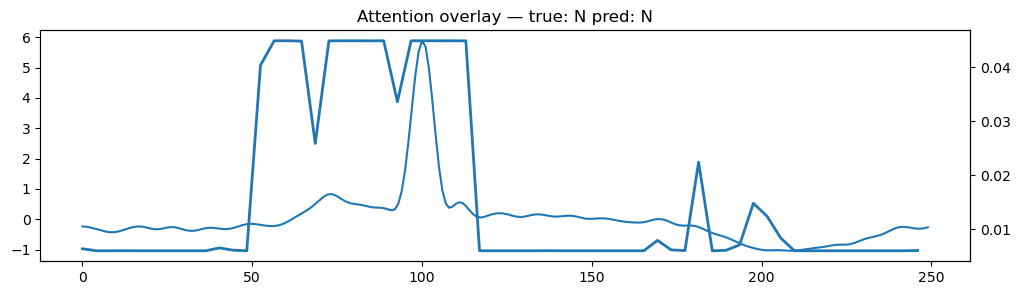

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


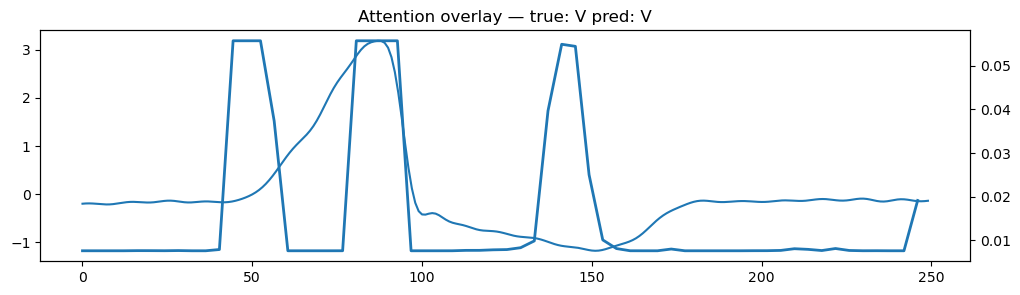

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


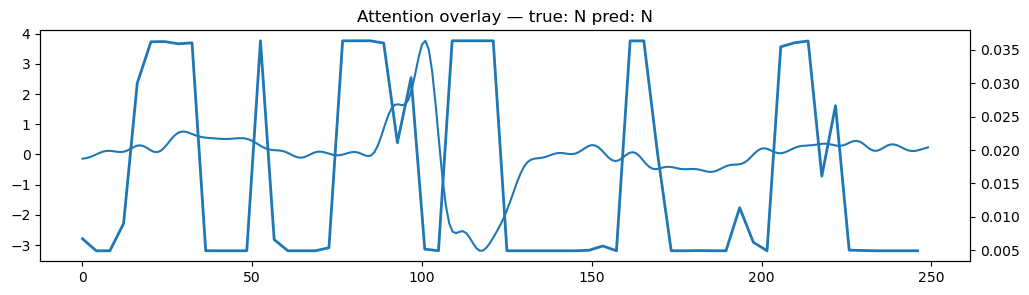

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


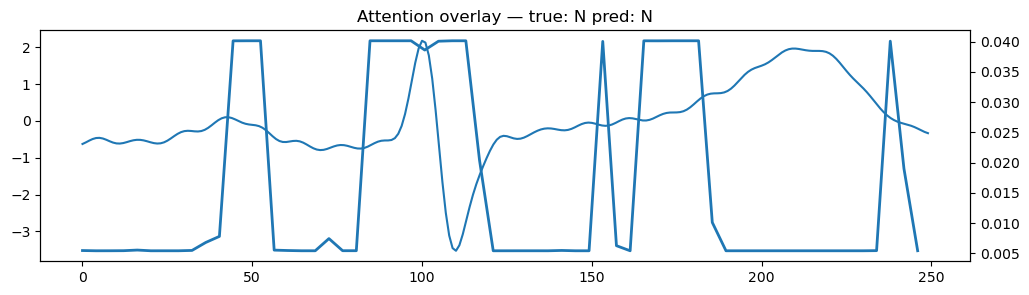

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


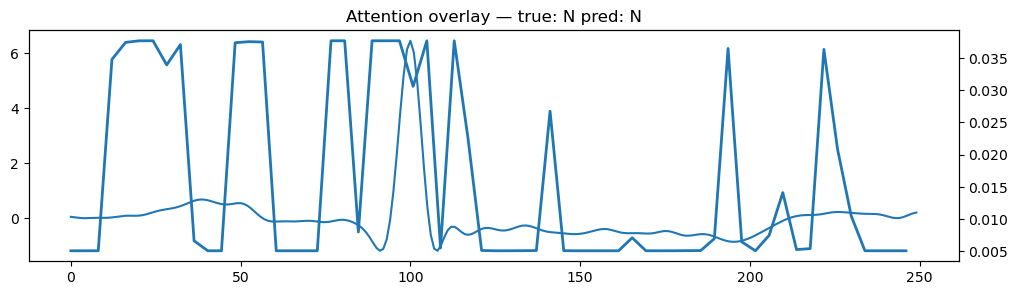

In [60]:
# Construct a model that returns both final softmax output and attention weights
# For that we need to rebuild the model or locate the attention weight layer by name.
# We named the activation 'attention_weights' inside attention_block.

# find the attention layer output tensor by name
try:
    att_layer = best.get_layer(name='attention_weights')
    # create model mapping input -> attention weights
    att_model = models.Model(inputs=best.input, outputs=att_layer.output)
except Exception as e:
    att_model = None
    print("Could not find attention layer by name. To visualize attention, rebuild the model to expose attention outputs. Error:", e)

# Visualize for a few validation samples
if att_model is not None:
    samples = 5
    idxs = np.random.choice(X_val.shape[0], samples, replace=False)
    for idx in idxs:
        sample = X_val[idx:idx+1]  # shape (1, L, 1)
        att = att_model.predict(sample)   # shape (1, time) because we used Flatten->softmax
        att = att[0]   # (time,)
        plt.figure(figsize=(12,3))
        plt.plot(sample.flatten(), label='beat')
        plt.twinx()
        plt.plot(np.arange(len(att)) * (len(sample.flatten())/len(att)), att, linewidth=2)
        plt.title(f"Attention overlay — true: {classes[y_val_int[idx]]} pred: {classes[y_pred_int[idx]]}")
        plt.show()
else:
    print("Attention visualization skipped (attention layer not available as model output).")
